In [1]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
from wrf import getvar, ALL_TIMES
from metpy.calc import wet_bulb_temperature, dewpoint_from_specific_humidity
from metpy.units import units
import matplotlib.animation as animation
from IPython.display import HTML

In [10]:
# file path to the wrfout files
file_path = '/data/scratch/a/kevintg2/AlisonCapstone/exampleWRFoutput/wrfout_d01_2024-12-15_00:00:00'
data = xr.open_dataset(file_path)

In [11]:
for var_name, da in data.data_vars.items():
    description = da.attrs.get("description", "No description available")
    print(f"{var_name}: {description}")

Times: No description available
LU_INDEX: LAND USE CATEGORY
ZNU: eta values on half (mass) levels
ZNW: eta values on full (w) levels
ZS: DEPTHS OF CENTERS OF SOIL LAYERS
DZS: THICKNESSES OF SOIL LAYERS
VAR_SSO: variance of subgrid-scale orography
BATHYMETRY_FLAG: Flag for bathymetry in the global attributes for metgrid data
U: x-wind component
V: y-wind component
W: z-wind component
PH: perturbation geopotential
PHB: base-state geopotential
T: perturbation potential temperature theta-t0
THM: either 1) pert moist pot temp=(1+Rv/Rd Qv)*(theta)-T0, or 2) pert dry pot temp=t
HFX_FORCE: SCM ideal surface sensible heat flux
LH_FORCE: SCM ideal surface latent heat flux
TSK_FORCE: SCM ideal surface skin temperature
HFX_FORCE_TEND: SCM ideal surface sensible heat flux tendency
LH_FORCE_TEND: SCM ideal surface latent heat flux tendency
TSK_FORCE_TEND: SCM ideal surface skin temperature tendency
MU: perturbation dry air mass in column
MUB: base state dry air mass in column
NEST_POS: -
P: perturba

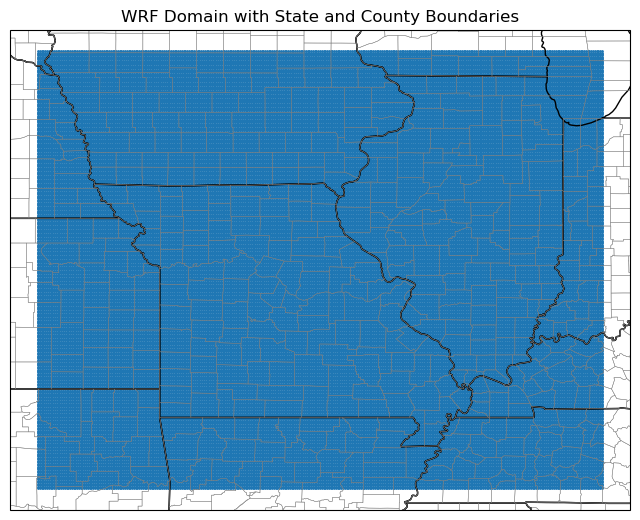

In [12]:
# Plotting region
lats = data.XLAT.isel(Time=0)
lons = data.XLONG.isel(Time=0)

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=proj)

# Plot WRF grid points
ax.scatter(lons.values, lats.values, s=1, transform=ccrs.PlateCarree())

# Add state and county boundaries
ax.add_feature(cfeature.STATES, linewidth=1)
counties = cfeature.NaturalEarthFeature(category='cultural', name='admin_2_counties', scale='10m', facecolor='none')
ax.add_feature(counties, edgecolor='gray', linewidth=0.3)

ax.set_title("WRF Domain with State and County Boundaries")
plt.show()

Lessons Learned: Above is a figure looking at the WRF domain with the state and county boundaries plotted. You might think this was one of the first things I did, but it was not. After coding up the FRAM math implementation codebase and running it for the WRF domain, I realized my method was much too simple. In the Sanders and Barjenbruch paper, they did not run averages over a state/county, compute domain means, or run FRAM on broad spatial averages. The analysis of Ice-To-Liquid Ratios was derived from individual ASOS stations and observations from that site. FRAM fundamentally operates as a POINT-BASED MODEL, which is why my initial attempt at domain averaging was problematic. Especially with a moving storm. Utilizing a domain mean as I had would artificially reduce precipitation rate, artificially raise wet-bulb temperature, and underestimate ice accretion. 

FRAM should be applied at the gridpoint level. 

Averaging meteorology before nonlinear accretion modeling = bias. 
FRAM is nonlinear in: Wet-bulb, Wind, Precip rate
So: FRAM(mean inputs) ≠ mean(FRAM at gridpoints)

In [13]:
# Testing On All Files

In [13]:
import glob

path = "/data/keeling/a/alison8/AlisonCapstone/archive_20241214/wrfout_d01_*"
files = sorted(glob.glob(path))
print(f"Number of files found: {len(files)}")

Number of files found: 97


In [14]:
times = []
wind_list = []
wetbulb_list = []
precip_list = []

for i in range(len(files)):
    ds = xr.open_dataset(files[i])
    
    # TIME
    time_str = "".join(ds.Times.values.astype(str))
    valid_time = np.datetime64(time_str.replace("_", " "))
    times.append(valid_time)
    
    # WIND SPEED (full grid)
    wind = np.sqrt(ds.U10**2 + ds.V10**2)
    wind_list.append(wind.squeeze())  # remove Time dim if present
    
    # WET BULB (full grid)
    pressure = (ds.PSFC / 100.0) * units.hPa
    temperature = (ds.T2 - 273.15) * units.degC
    specific_humidity = ds.Q2 * units.dimensionless
    dewpoint = dewpoint_from_specific_humidity(pressure, temperature, specific_humidity)
    wetbulb = wet_bulb_temperature(pressure, temperature, dewpoint).metpy.convert_units("degC")
    wetbulb_da = wetbulb.squeeze()
    wetbulb_list.append(wetbulb_da)
    
    # PRECIP RATE (full grid)
    if i > 0:
        ds_prev = xr.open_dataset(files[i-1])
        total_prev = ds_prev.RAINC + ds_prev.RAINNC
        total_now  = ds.RAINC + ds.RAINNC
        rate = (total_now - total_prev) / 0.5  # mm/hr
        precip_list.append(rate.squeeze())
        ds_prev.close()
    else:
        precip_list.append(xr.zeros_like(ds.RAINC.squeeze()))
    
    ds.close()

/data/keeling/a/alison8/miniconda3/envs/ATMS596/lib/python3.13/site-packages/metpy/calc/thermo.py:1753: RuntimeWarning: invalid value encountered in log
  val = np.log(vapor_pressure / mpconsts.nounit.sat_pressure_0c)


In [19]:
# Concatenate along time
wind_all = xr.concat(wind_list, dim="time")
wetbulb_all = xr.concat(wetbulb_list, dim="time")
precip_all = xr.concat(precip_list, dim="time")
wind_all = wind_all.assign_coords(time=times)
wetbulb_all = wetbulb_all.assign_coords(time=times)
precip_all = precip_all.assign_coords(time=times)

# Remove leftover WRF time coordinate if present
for da in [wind_all, wetbulb_all, precip_all]:
    if "XTIME" in da.coords:
        da = da.drop_vars("XTIME")

# Explicitly drop XTIME
wind_all = wind_all.drop_vars("XTIME", errors="ignore")
wetbulb_all = wetbulb_all.drop_vars("XTIME", errors="ignore")
precip_all = precip_all.drop_vars("XTIME", errors="ignore")

# Build clean dataset
ds_full = xr.Dataset({
    "wind_speed": wind_all,
    "wetbulb": wetbulb_all,
    "precip_rate": precip_all
})

ds_clean = ds_full[["precip_rate", "wind_speed", "wetbulb"]]
if "Time" in ds_clean.dims:
    ds_clean = ds_clean.rename({"Time": "time"})
ds_clean.attrs["description"] = "WRF-derived FRAM input variables"
ds_clean.attrs["time_resolution"] = "30 minutes"
ds_clean.attrs["units"] = "precip_rate=mm/hr, wind_speed=m/s, wetbulb=degC"

encoding = {
    var: {"zlib": True, "complevel": 4}
    for var in ds_clean.data_vars
}

ds_clean.to_netcdf("/data/keeling/a/alison8/AlisonCapstone/wrf_framinputs_14dec2024.nc", encoding=encoding)

In [2]:
ds_clean = xr.open_dataset("/data/keeling/a/alison8/AlisonCapstone/wrf_framinputs_14dec2024.nc")

In [3]:
print(ds_clean.dims)
print(ds_clean.coords)

FrozenMappingWarningOnValuesAccess({'time': 97, 'south_north': 319, 'west_east': 319})
Coordinates:
  * time     (time) datetime64[ns] 776B 2024-12-14 ... 2024-12-16
    XLAT     (south_north, west_east) float32 407kB ...
    XLONG    (south_north, west_east) float32 407kB ...


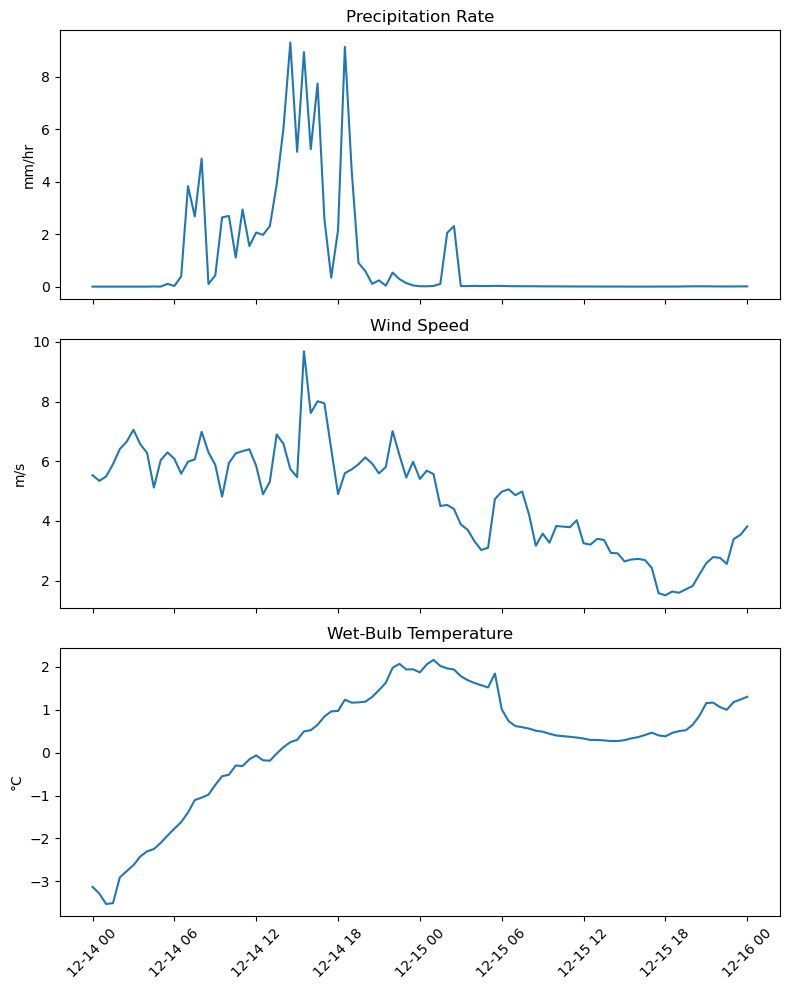

In [4]:
# plot a single grid point
i = 160
j = 160
point = ds_clean.isel(south_north=i, west_east=j)

fig, axs = plt.subplots(3, 1, figsize=(8, 10), sharex=True)
axs[0].plot(point.time, point.precip_rate)
axs[0].set_ylabel("mm/hr")
axs[0].set_title("Precipitation Rate")
axs[1].plot(point.time, point.wind_speed)
axs[1].set_ylabel("m/s")
axs[1].set_title("Wind Speed")
axs[2].plot(point.time, point.wetbulb)
axs[2].set_ylabel("°C")
axs[2].set_title("Wet-Bulb Temperature")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("singlegridpoint_timeseries.png", dpi=300)
plt.show()

In [8]:
lats = ds.XLAT.isel(time=0)
lons = ds.XLONG.isel(time=0)

proj = ccrs.PlateCarree()

def setup_map(ax):
    ax.add_feature(cfeature.STATES, linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=1)
    counties = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_2_counties',
        scale='10m',
        facecolor='none'
    )
    ax.add_feature(counties, edgecolor='gray', linewidth=0.3)

NameError: name 'ds' is not defined

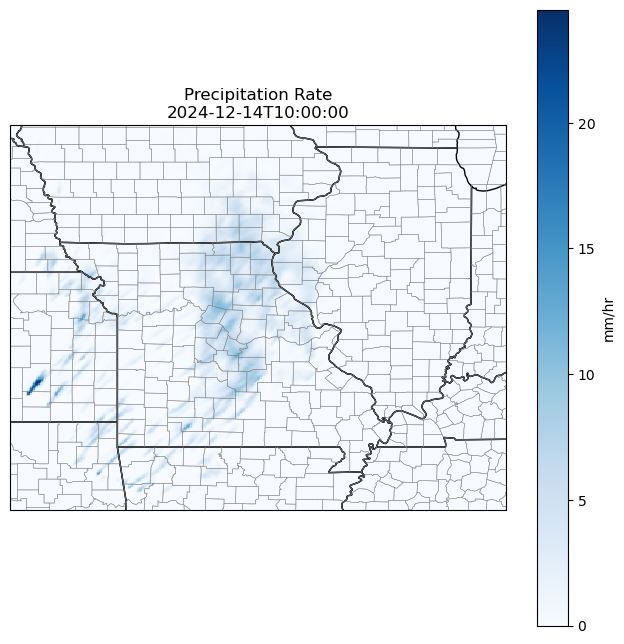

In [40]:
t = 20  # choose time

fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=proj)
pcm = ax.pcolormesh(lons, lats, ds_clean.precip_rate.isel(time=t), cmap="Blues", transform=ccrs.PlateCarree())
setup_map(ax)
plt.colorbar(pcm, ax=ax, label="mm/hr")
plt.title(f"Precipitation Rate\n{ds_clean.time.values[t]}")
plt.savefig("snapshot_precip.png", dpi=300)
plt.show()

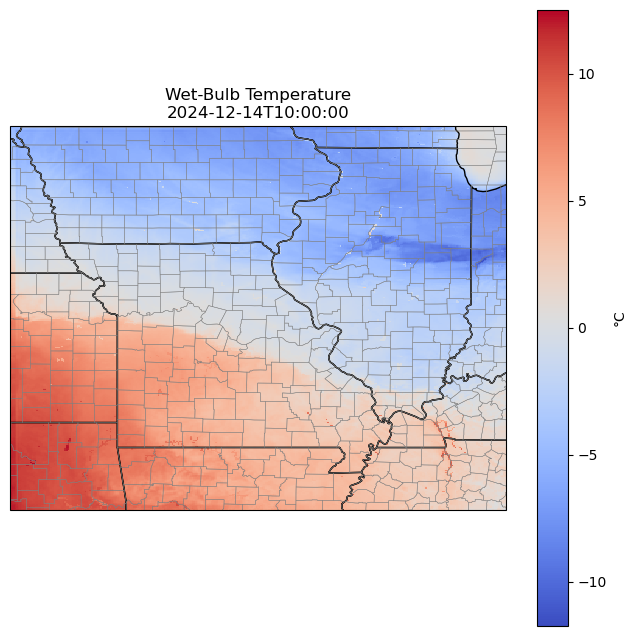

In [41]:
fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=proj)
pcm = ax.pcolormesh(lons, lats, ds_clean.wetbulb.isel(time=t), cmap="coolwarm", transform=ccrs.PlateCarree())
setup_map(ax)
plt.colorbar(pcm, ax=ax, label="°C")
plt.title(f"Wet-Bulb Temperature\n{ds_clean.time.values[t]}")
plt.savefig("snapshot_wetbulb.png", dpi=300)
plt.show()

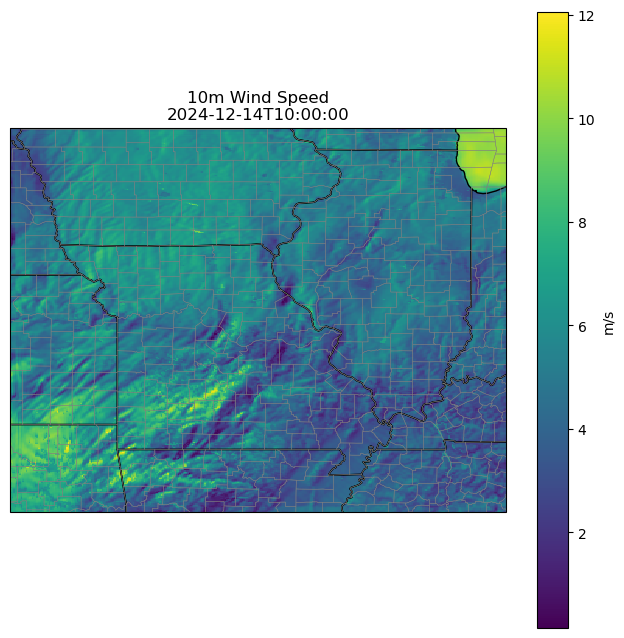

In [42]:
fig = plt.figure(figsize=(8,8))
ax = plt.axes(projection=proj)
pcm = ax.pcolormesh(lons, lats, ds_clean.wind_speed.isel(time=t), cmap="viridis", transform=ccrs.PlateCarree())
setup_map(ax)
plt.colorbar(pcm, ax=ax, label="m/s")
plt.title(f"10m Wind Speed\n{ds_clean.time.values[t]}")
plt.savefig("snapshot_windspeed.png", dpi=300)
plt.show()

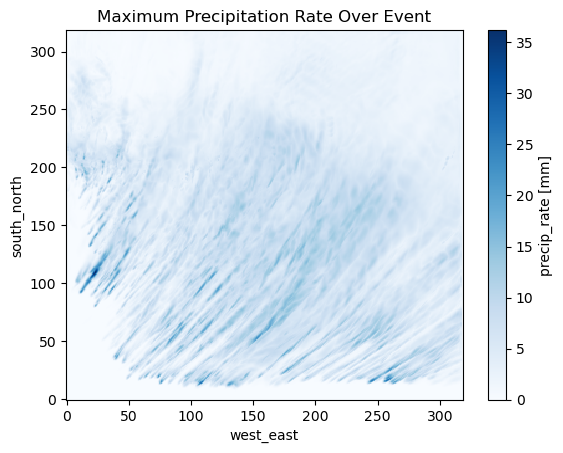

In [43]:
# maximum precipitation over time period
precip_max = ds_clean.precip_rate.max(dim="time")
precip_max.plot(cmap="Blues")
plt.title("Maximum Precipitation Rate Over Event")
plt.savefig("max_precip_map.png", dpi=300)
plt.show()

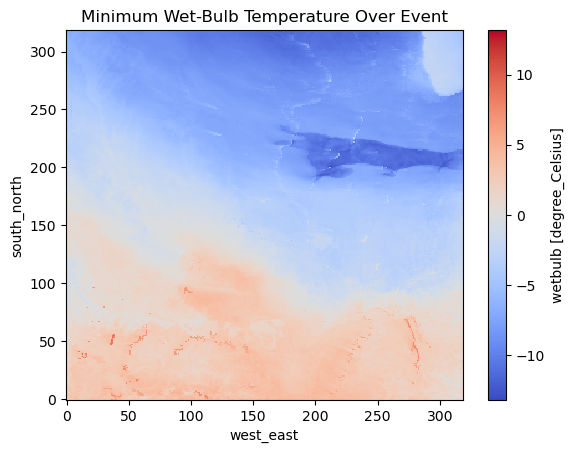

In [45]:
# minimum wetbulb over time period
wetbulb_min = ds_clean.wetbulb.min(dim="time")
wetbulb_min.plot(cmap="coolwarm")
plt.title("Minimum Wet-Bulb Temperature Over Event")
plt.savefig("min_wetbulb_map.png", dpi=300)
plt.show()

In [53]:
# animation of three variables over time (for fun :) )
fig = plt.figure(figsize=(15, 5))
ax1 = fig.add_subplot(1, 3, 1, projection=proj)
ax2 = fig.add_subplot(1, 3, 2, projection=proj)
ax3 = fig.add_subplot(1, 3, 3, projection=proj)
for ax in [ax1, ax2, ax3]:
    setup_map(ax)

# Initial fields
pcm1 = ax1.pcolormesh(lons, lats, ds_clean.precip_rate.isel(time=0), cmap="Blues", transform=ccrs.PlateCarree())
pcm2 = ax2.pcolormesh(lons, lats, ds_clean.wind_speed.isel(time=0), cmap="viridis", transform=ccrs.PlateCarree())
pcm3 = ax3.pcolormesh(lons, lats, ds_clean.wetbulb.isel(time=0), cmap="coolwarm", transform=ccrs.PlateCarree())
fig.colorbar(pcm1, ax=ax1, orientation='vertical', fraction=0.046)
fig.colorbar(pcm2, ax=ax2, orientation='vertical', fraction=0.046)
fig.colorbar(pcm3, ax=ax3, orientation='vertical', fraction=0.046)
title = fig.suptitle(str(ds_clean.time.values[0]), fontsize=14)

def update(frame):
    pcm1.set_array(ds_clean.precip_rate.isel(time=frame).values.ravel())
    pcm2.set_array(ds_clean.wind_speed.isel(time=frame).values.ravel())
    pcm3.set_array(ds_clean.wetbulb.isel(time=frame).values.ravel())
    title.set_text(str(ds_clean.time.values[frame]))
    return pcm1, pcm2, pcm3, title

ani = animation.FuncAnimation(fig, update, frames=len(ds_clean.time), interval=200) # 200ms between frames
HTML(ani.to_jshtml())
ani.save("wrf_event_evolution.mp4", dpi=200, writer="ffmpeg")
ani.save("wrf_event_evolution.gif", dpi=150, writer="pillow")

<IPython.core.display.Javascript object>

/data/keeling/a/alison8/miniconda3/envs/ATMS596/lib/python3.13/site-packages/matplotlib/animation.py:908: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(
Animation size has reached 21240839 bytes, exceeding the limit of 20971520.0. If you're sure you want a larger animation embedded, set the animation.embed_limit rc parameter to a larger value (in MB). This and further frames will be dropped.
